# Análise Exploratória de Dados do Airbnb em Nova York

Este projeto tem como objetivo analisar os dados de acomodações do Airbnb em Nova York, identificar padrões de preço, comportamento das acomodações e gerar insights de negócio a partir dos dados.

## Objetivo

Entender quais fatores estão mais relacionados ao preço das acomodações e identificar padrões relevantes entre localização, tipo de acomodação, número de avaliações e disponibilidade.

## 1. Importação das bibliotecas   

In [114]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

import geopandas as gpd

from PIL import Image

## 2. Carregamento da base de dados

In [ ]:
#pull dataframe
df = pd.read_csv("C:/Users/joaop/OneDrive/Documentos/Programação/Projects/airbnb-price-analysis/data/raw/AB_NYC_2019.csv")

## 3. Entendimento inicial dos dados

Nesta etapa, vamos analisar a estrutura do dataset, tipos de variáveis, volume de dados e possíveis valores ausentes.

In [132]:
#show first 5 lines of df
df.head()

,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price_per_night_minimum
0,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,149.000000
1,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,225.000000
3,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,89.000000
4,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,8.000000
5,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,0.59,1,129,66.666667


In [116]:
#number of lines and collums
df.shape

(48895, 16)

In [117]:
#data type and null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [118]:
#media, min, max e quarts
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [119]:
#verify null values
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

## 4. Limpeza e tratamento dos dados

Aqui serão removidas colunas irrelevantes, tratados valores ausentes e ajustadas inconsistências para preparar a base para análise.

In [120]:
#data cleaning
try:
    df = df.drop(columns=["id",'host_id','last_review','name'])
except:
    print('Limpeza concluida!')


In [121]:
#remove null values
df = df.dropna()

## 5. Análise exploratória

Nesta etapa, vamos investigar distribuições, comparar variáveis e identificar padrões relevantes nos dados.

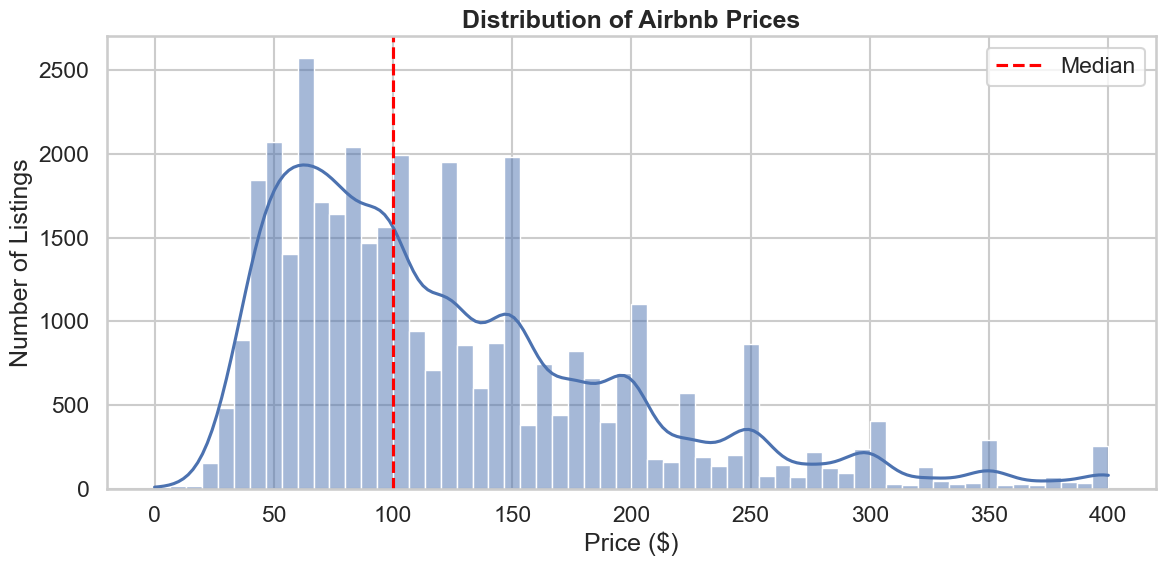

In [140]:
sns.set_theme(style="whitegrid", context="talk")

price_limit = df['price'].quantile(0.99)

plt.figure(figsize=(12,6))

sns.histplot(
    df[df['price'] <= price_limit]['price'],
    bins=60,
    kde=True,
    color="#4C72B0"
)

plt.axvline(df['price'].median(), color='red', linestyle='--', label='Median')

plt.title("Distribution of Airbnb Prices", fontsize=18, weight='bold')
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")
plt.savefig("../images/distribuicao_precos.png", bbox_inches="tight")
plt.legend()
plt.tight_layout()

plt.show()

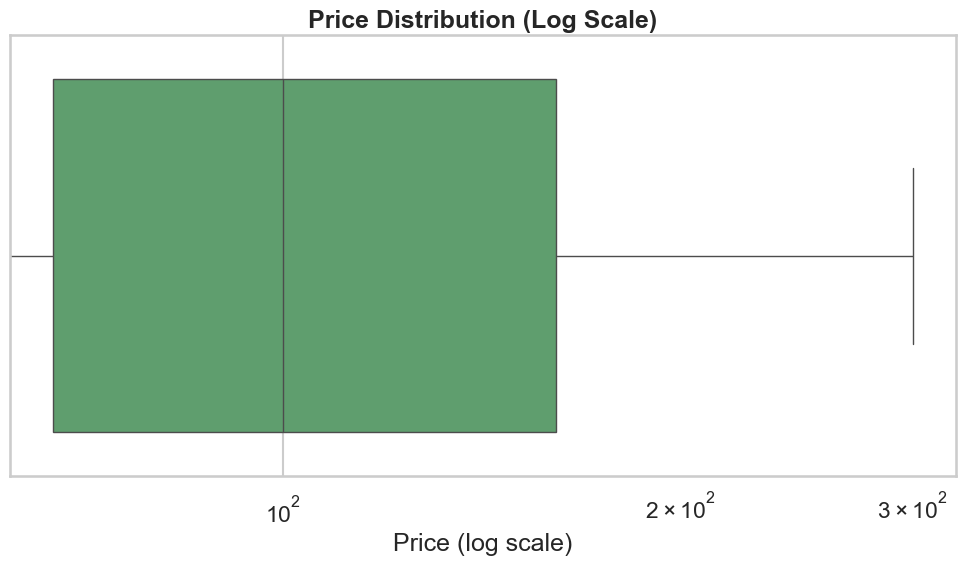

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['price'],
    color="#55A868",
    showfliers=False
)

plt.xscale('log')

plt.title("Price Distribution (Log Scale)", fontsize=18, weight='bold')
plt.xlabel("Price (log scale)")
plt.savefig("../images/outliers_preco.png", bbox_inches="tight")
plt.tight_layout()

plt.show()

In [124]:
#remove outliers
df = df[df['price'] < 500]


C:\Users\joaop\AppData\Local\Temp\ipykernel_10496\936138096.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


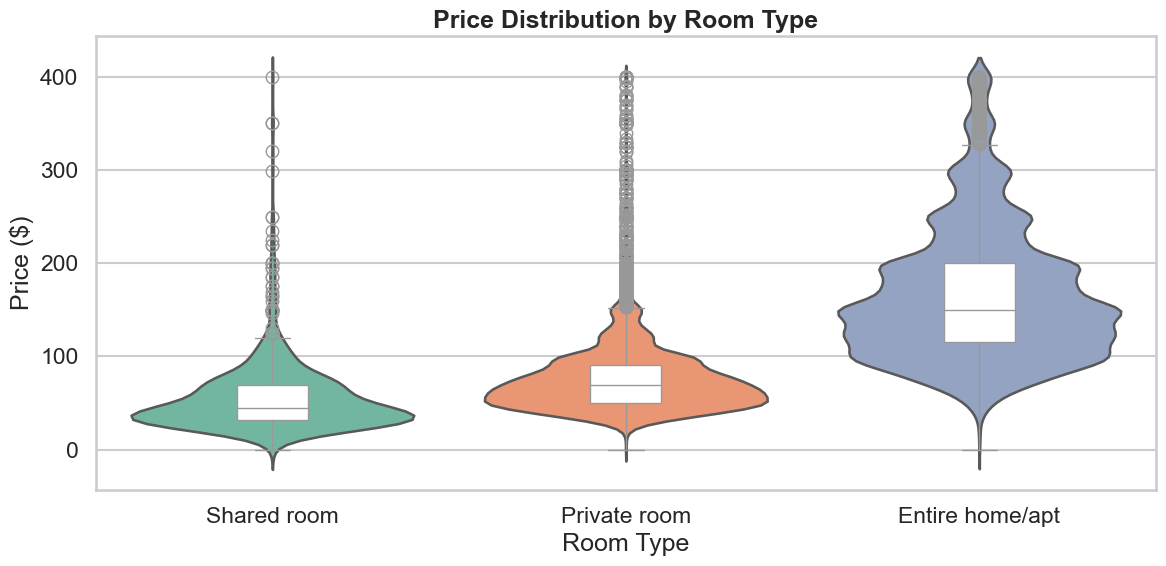

In [142]:
plt.figure(figsize=(12,6))

price_limit = df['price'].quantile(0.99)
df_filtered = df[df['price'] <= price_limit]

order = df_filtered.groupby('room_type')['price'].median().sort_values().index

sns.violinplot(
    x='room_type',
    y='price',
    data=df_filtered,
    order=order,
    inner=None,
    palette="Set2"
)

sns.boxplot(
    x='room_type',
    y='price',
    data=df_filtered,
    order=order,
    width=0.2,
    color='white'
)

plt.title("Price Distribution by Room Type", fontsize=18, weight='bold')
plt.xlabel("Room Type")
plt.ylabel("Price ($)")
plt.savefig("../images/preco_por_tipo.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

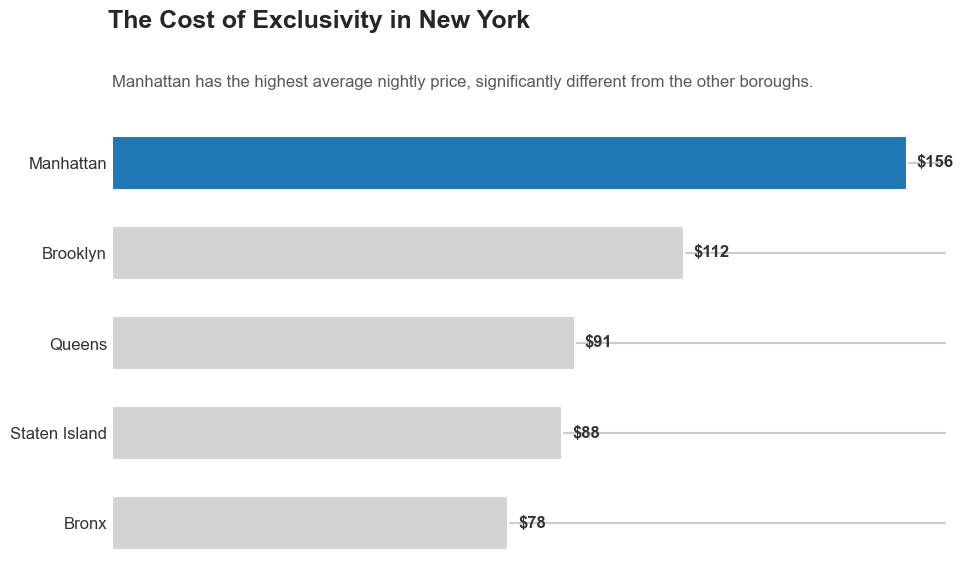

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

cores = ['#d3d3d3' if bairro != 'Manhattan' else '#1f77b4' for bairro in neighbourhood_price.index]

barras = ax.barh(neighbourhood_price.index, neighbourhood_price.values, color=cores, height=0.6)

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

ax.xaxis.set_visible(False) 
ax.tick_params(axis='y', length=0, labelsize=12, labelcolor='#333333') 

for barra in barras:
    largura = barra.get_width()
    ax.text(largura + 2, barra.get_y() + barra.get_height()/2, 
            f'${largura:.0f}',
            ha='left', va='center', fontsize=12, fontweight='bold', color='#333333')

fig.suptitle('The Cost of Exclusivity in New York', 
             fontsize=18, fontweight='bold', color='#262626', x=0.125, ha='left')

ax.set_title('Manhattan has the highest average nightly price, significantly different from the other boroughs.', 
             fontsize=12, color='#595959', loc='left', pad=20)

plt.savefig("../images/preco_por_regiao.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

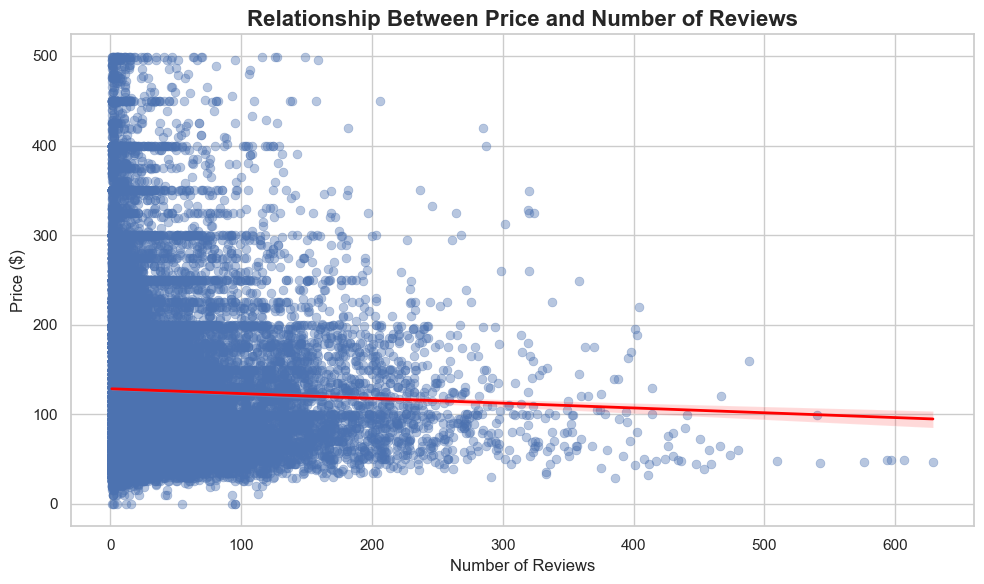

In [144]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="number_of_reviews",
    y="price",
    alpha=0.4,
    s=40,
    edgecolor=None
)

sns.regplot(
    data=df,
    x="number_of_reviews",
    y="price",
    scatter=False,
    color="red",
    line_kws={"linewidth":2}
)

plt.title("Relationship Between Price and Number of Reviews", fontsize=16, weight="bold")
plt.xlabel("Number of Reviews", fontsize=12)
plt.ylabel("Price ($)", fontsize=12)
plt.savefig("../images/reviews_vs_preco.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

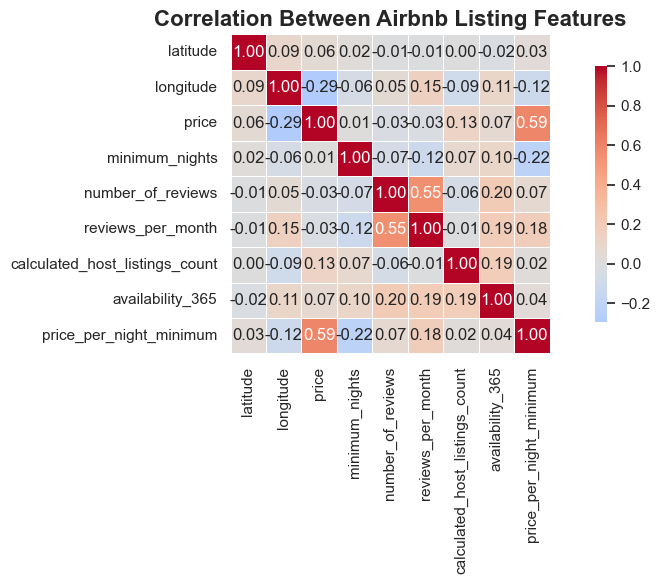

In [145]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink":0.8}
)

plt.title("Correlation Between Airbnb Listing Features", fontsize=16, weight="bold")
plt.savefig("../images/correlacao.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

In [129]:
#Feature engeneering

df['price_per_night_minimum'] = df['price'] / df['minimum_nights']

In [130]:
#Convert dataframe to geoespacial
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude)
)

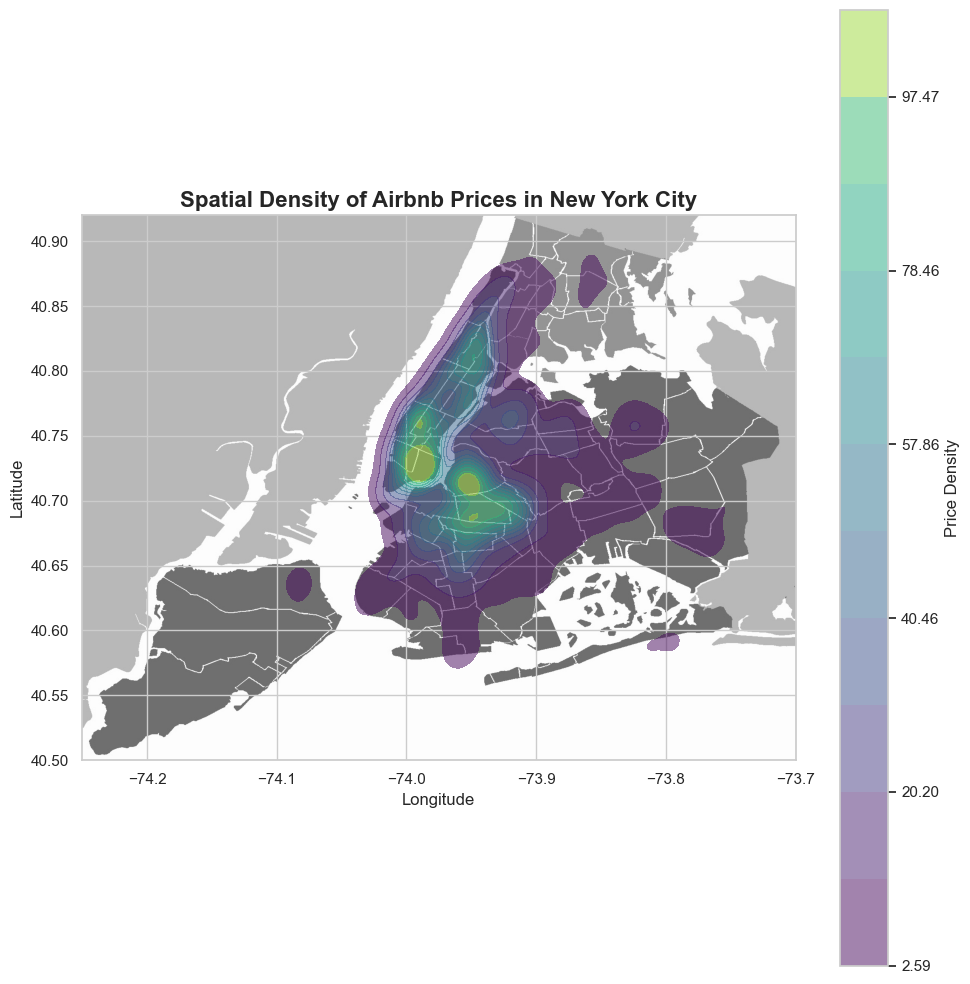

In [146]:
img = Image.open("nyc_map.png")
nyc_map = np.array(img)

plt.figure(figsize=(10,10))

# plot map
plt.imshow(nyc_map, extent=[-74.25, -73.70, 40.50, 40.92])

# densidade
kde = sns.kdeplot(
    data=df,
    x="longitude",
    y="latitude",
    fill=True,
    cmap="viridis",
    alpha=0.5,
    levels=12,
    thresh=0.05   # remove low density areas
)

cbar = plt.colorbar(kde.collections[0])
cbar.set_label("Price Density")

# lock map scale
plt.xlim(-74.25, -73.70)
plt.ylim(40.50, 40.92)

plt.title(
    "Spatial Density of Airbnb Prices in New York City",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig("../images/mapa_geografico_precos.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

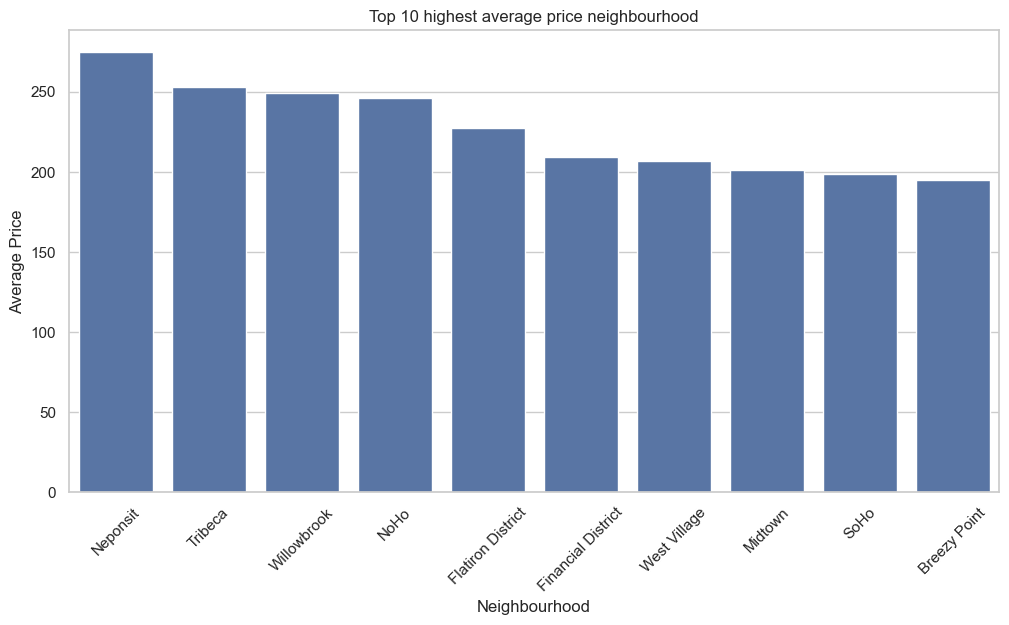

In [ ]:
top_bairros = (
    df.groupby("neighbourhood")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(x=top_bairros.index, y=top_bairros.values)
plt.title("Top 10 highest average price neighbourhood")
plt.xlabel("Neighbourhood")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.savefig("../images/top10_bairros_preco.png", bbox_inches="tight")
plt.show()

In [155]:
room_summary = df.groupby("room_type").agg(
    listings=("room_type", "count"),
    average_price=("price", "mean"),
    average_reviews=("number_of_reviews", "mean")
).reset_index()

room_summary = room_summary.round(2)

room_summary

,room_type,listings,average_price,average_reviews
0,Entire home/apt,19674,172.72,28.82
1,Private room,17577,79.09,30.57
2,Shared room,840,56.58,22.88


## 6. Principais insights

A análise indica que o preço das acomodações varia principalmente de acordo com o tipo de imóvel e a localização. Além disso, regiões mais valorizadas concentram anúncios com preços mais altos, enquanto acomodações com maior número de avaliações tendem a apresentar preços mais competitivos.

Principais insights:

1- Apartamentos inteiros possuem preço médio significamente maior.

2- Manhattan concentra os preços mais altos.

3- Listings com muitos reviews tendem a ter preços mais baixos.

4- Existe concentração geográfica de preços altos no centro da cidade.

## 7. Conclusão

O projeto mostrou que variáveis como tipo de acomodação, localização e volume de avaliações ajudam a entender a precificação dos anúncios do Airbnb. A análise exploratória permitiu identificar padrões importantes e construir uma visão inicial sólida sobre o mercado de hospedagem em Nova York.

In [147]:
df.to_csv("../data/processed/airbnb_cleaned.csv", index=False)